# Calcolo della velocità della luce
Giovanni Nicola D'Aloisio, n. di matricola 494722; prova svolta il 26 maggio 2021.

---

## Introduzione
<p align="justify">Per molti secoli si ritenne che la luce fosse un fenomeno capace di propagarsi con velocità infinita; Galileo Galilei pur avendo adottato un metodo concettualmente corretto, non riuscì a concludere nulla. Fu Olaf Roemer il primo a darne con successo una prima stima nel Seicento, osservando che il moto di Io, il più interno dei satelliti medicei, non si ripeteva regolarmente nel tempo ma con un ritardo complessivo di circa 20 minuti. Hyppolite Fizeau raggiunse lo stesso traguardo, ma con maggiore accuratezza, utilizzando 2 specchi distanziati di 8 chilometri e una ruota dentata. Soltanto con Foucault si realizzò il primo esperimento che consentiva di misurare la velocità della luce entro le mura di un laboratorio, impiegando un articolato sistema di specchi capace di fornire lo stesso valore con accuratezza più grande.

## Scopi della prova
Gli obiettivi di questa prova sono:
* Misurare la velocità della luce in aria con il metodo di Foucault;
* Misurare la velocità della luce in aria con il metodo del tempo di volo.

## Apparato sperimentale

### Metodo di Foucault
Per la realizzazione della prova con il metodo di Foucault si dispone di:
* un laser, che costituisce una sorgente di luce altamente concentrata;
* uno specchio a quattro facce vincolato a un motore elettrico a velocità variabile;
* un oscilloscopio, che misurando la frequenza della tensione periodica prodotta dalla riflessione del fascio laser con lo specchio rotante su un fotodiodo restituisce il valore della frequenza di rotazione dello specchio;
* un sensore CCD, che permette di fotografare lo spot luminoso che ritorna dallo specchio rotante;
* un paio di lenti convesse, che contribuiscono a focalizzare il fascio di luce in posizioni intermedie alla sorgente e allo specchio rotante;
* un metro a nastro, per misurare le distanze coinvolte nell'esperimento.

### Metodo del tempo di volo
Per la prova con il metodo del tempo di volo, invece, sono necessari:
* un laser, che costituisce una sorgente di luce altamente concentrata, alimentato da un generatore di frequenze costante;
* uno specchio capace di traslare su una rotaia mobile graduata in millimetri, che riflette dell'altezza e dell'azimuth desiderato il fascio laser generato a una posizione nota;
* un oscilloscopio, che calcola il ritardo picco-picco tra il segnale prodotto dal generatore di funzioni e quello recepito dal fotodiodo dalla riflessione del fascio laser sullo specchio;
* una matita, per tenere traccia delle posizioni della rotaia relativamente ai ritardi misurati.

## Procedura

### Metodo di Foucault
<p align="justify">Supponendo la luce come insieme di particelle in moto rettilineo uniforme, si osserva che un impulso generato dal laser impiega un tempo $t={s \over c}$ per raggiungere lo specchio rotante, per poi riflettersi su uno specchio concavo e tornare su quello rotante. Se in tale $t$ quest'ultimo ruota di un angolo $\alpha = \omega t$, per la legge della riflessione il fascio viene deviato di un angolo $\vartheta = 2 \alpha$, dunque, se il tempo impiegato dalla luce per giungere sullo specchio rotante e ritornare sul sensore CCD è $t={2D \over c}$, allora:

> $L \simeq \vartheta D' = {8 \pi f D D' \over c}$

<p align="justify">Dunque, per una decina di valori di frequenza di rotazione dello specchio si misura la deviazione $L \pm \delta L$ tra lo spot considerato e il primo e, sapendo che $D \pm \delta D$ e $D' \pm \delta D'$ sono le distanze tra specchio rotante e specchio concavo e specchio rotante e sensore CCD, dal best-fit della retta ottenuta si ricava il valore $c \pm \delta c$.

### Metodo del tempo di volo

<p align="justify">Anche in questo caso la sorgente luminosa è un laser, ma la procedura è molto più semplice. Dopo aver percorso una certa distanza, la luce viene rilevata da un fotodiodo, e l'oscilloscopio determina il tempo trascorso tra l'emissione del fascio e il suo rilevamento (dato dalla distanza tra due picchi contigui delle due funzioni periodiche su un diagramma $V-t$).

<p align="justify">Supponendo di fissare l'origine del sistema di riferimento dello specchio mobile, e di conoscere in tale sistema di riferimento la distanza percorsa dalla luce, avente velocità costante, in ciascuna delle misure eseguite, per ogni coppia di valori $D \pm \delta D$ $\Delta t \pm \delta t$ si può costruire e fittare un grafico $D-\Delta t$ secondo la legge:

> $D = c \Delta t$

<p align="justify">La cui pendenza è, appunto, la velocità della luce.

## Analisi dei dati sperimentali

In questa sezione sono riportati gli script in Python utilizzati per l'analisi dei dati sperimentali, con i relativi risultati.

In [ ]:
# Da eseguire all'inizio
 
import numpy as np
from matplotlib import pyplot as plt 
from scipy.optimize import curve_fit 
from scipy import odr
from scipy import constants
import json

### Metodo di Foucault

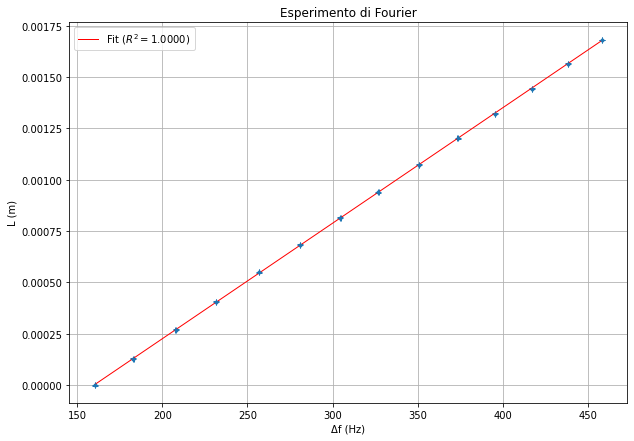

y₀ =    -0.0009 +/- 0.0000
c = 295468743.9109 +/- 348105.8060
R² = 0.9999833438323149


In [ ]:
# Importazione dati grezzi (S.I.)
 
frequenze = np.array([641.9, 732.2, 831.2, 926.1, 1027.7, 1123.4, 1218.2, 1307.5, 1403.2, 1493.3, 1580.5, 1667.3, 1752.4, 1831.5])
posizioni = np.array([0.0028301, 0.002702, 0.0025606, 0.0024241, 0.0022813, 0.0021462, 0.0020153, 0.0018907, 0.00175735, 0.0016296, 0.0015085, 0.00138635,0.0012649, 0.0011501])
frequenze_err = np.array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])
posizioni_err = np.array([0.00000105, 0.00000105, 0.00000105, 0.00000105, 0.00000105, 0.00000105, 0.00000105, 0.00000105, 0.00000105, 0.00000105, 0.00000105, 0.00000105, 0.00000105, 0.00000105])
 
D1, D2, D1_err, D2_err = 8.15, 8.12, 0.02, 0.02         # Distanze tra specchio rotante e specchio concavo e tra specchio rotante e sorgente
 
# Elaborazione distanze per fit
 
distance = []
 
for i in posizioni:
  l = (0.0028301 - i)
  distance.append(l)
 
distance = np.array(distance)
 
distance_err = []
 
for i in posizioni_err:
  l = 0.00000210
  distance_err.append(l)
 
distance_err = np.array(distance_err)
 
freq = []
 
for i in frequenze:
  j = i/4
  freq.append(j)
 
freq = np.array(freq)
 
freq_err = []
 
for i in frequenze_err:
  j = i/4
  freq_err.append(j)
 
freq_err = np.array(freq_err)
 
# Importazione dati per fit
 
kappa = freq
omega = distance
kappa_err = freq_err
omega_err = distance_err
 
# Definizione della funzione di fit
 
def retta(p,delta_x):
  return p[0]+(8*np.pi*D1*D2/p[1])*delta_x           # f = delta_x
 
# Fitting routine, per definire la funzione che stampa il grafico e eseguire il fit dei dati
 
def fitplot_retta(y0, c, print_output=True, plot_guess=False):
  retta_model = odr.Model(retta)
  fit_data = odr.RealData(kappa, omega, sx=kappa_err, sy=omega_err)
  
  beta0 = np.array([y0,c])                           # Array dei guess iniziali
  
  fit = odr.ODR(fit_data, retta_model, beta0=beta0)
 
  global out
  
  out = fit.run()
  
  # Calcolo di R_squared, che valuta la bontà del fit
 
  residuals = omega - retta(out.beta, kappa)
  ss_res = np.sum(residuals**2)
  ss_tot = np.sum((omega-np.mean(omega))**2)
  r_squared = 1 - (ss_res / ss_tot)
  
  # Plot dei risultati del fit
 
  sample_x = np.linspace(np.amin(kappa),np.amax(kappa), 1000)
  plt.show()
  plt.figure(figsize=(10,7))
 
  if plot_guess:
    plt.plot(sample_x, retta(beta0,sample_x),'-', color=[0.3,0.7,0], label="Guess", linewidth=2)
  
  plt.errorbar(kappa, omega, xerr=kappa_err, yerr=omega_err, linestyle='None', capsize=3, marker='.')
  plt.title("Esperimento di Foucault")
  plt.xlabel("Δf (Hz)")
  plt.ylabel("L (m)")
  plt.plot(sample_x, retta(out.beta, sample_x), color=[1,0,0], label="Fit ($R^2=${:.4f})".format(r_squared), linewidth=1)
  plt.grid(which='both')
  plt.legend()
  plt.show()
  
  if print_output:
    print("y₀ = {:10.4f} +/- {:2.4f}".format(out.beta[0],out.sd_beta[0]))
    print("c = {:10.4f} +/- {:2.4f}".format(out.beta[1],out.sd_beta[1]))
    print("R² = "+str(r_squared))
 
fitplot_retta(0, 300000000)

### Metodo del tempo di volo

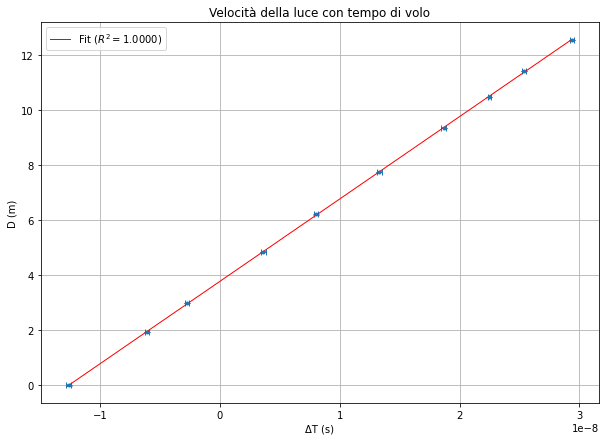

y₀ =     3.7815 +/- 0.0092
c = 299505057.1861 +/- 544030.4757
R² = 0.9999767241540439


In [ ]:
# Importazione dati temporali

# tempi è una lista di liste del tipo [tempo, incertezza] calcolate come media e semidispersione massima di un range in nanosecondi
# Le righe commmentate contengono la prima, che è quella di offset

# tempi = [-(13.91+14.18)/2, -(12.81+12.41)/2, -(6.23+5.88)/2, -(2.590+2.908)/2, (3.45+3.82)/2, (8.21+7.89)/2, (13.49+13.14)/2, (18.84+18.49)/2, (22.64+22.33)/2, (25.58+25.23)/2, (29.51+29.17)/2]
# tempi_incertezze = [(14.18-13.91)/2, (12.81-12.41)/2, (6.23-5.88)/2, (2.590-2.908)/2, (3.82-3.45)/2, (8.21-7.89)/2, (13.49-13.14)/2, (18.84-18.49)/2, (22.64-22.33)/2, (25.58-25.23)/2, (29.51-29.17)/2]

tempi = [-(12.81+12.41)/2, -(6.23+5.88)/2, -(2.590+2.908)/2, (3.45+3.82)/2, (8.21+7.89)/2, (13.49+13.14)/2, (18.84+18.49)/2, (22.64+22.33)/2, (25.58+25.23)/2, (29.51+29.17)/2]
tempi_incertezze = [(12.81-12.41)/2, (6.23-5.88)/2, (2.590-2.908)/2, (3.82-3.45)/2, (8.21-7.89)/2, (13.49-13.14)/2, (18.84-18.49)/2, (22.64-22.33)/2, (25.58-25.23)/2, (29.51-29.17)/2]

# Sovrascrittura dati in unità S.I.

time = []

for i in tempi:
  j = i*(10**(-9))
  time.append(j)

time = np.array(time)               # Array dei tempi

time_err = []

for u in tempi_incertezze:
  v = u*(10**(-9))
  time_err.append(v)

time_err = np.array(time_err)       # Array degli errori

# Importazione dati spaziali e conversione per tempi di andata e ritorno

distanze = [0.212, 1.185, 1.704, 2.639, 3.319, 4.095, 4.896, 5.455, 5.923, 6.495]

deltaX = []

for i in distanze:
  j = (i - distanze[0])*2
  deltaX.append(j)

deltaX = np.array(deltaX)

deltaX_err = np.array([0.004, 0.004, 0.004, 0.004, 0.004, 0.004, 0.004, 0.004, 0.004, 0.004])

# Importazione dei dati per il fit

kappa = time
omega = deltaX
kappa_err = time_err
omega_err = deltaX_err

# Definizione della funzione di fit
 
def retta(p,delta_x): 
  return p[0]+p[1]*delta_x
 
# Fitting routine, per definire la funzione che stampa il grafico e eseguire il fit dei dati
 
def fitplot_retta(y0, c, print_output=True, plot_guess=False):
  retta_model = odr.Model(retta)
  fit_data = odr.RealData(kappa, omega, sx=kappa_err, sy=omega_err)
  
  beta0 = np.array([y0,c])                                                      # Array dei guess iniziali
  
  fit = odr.ODR(fit_data, retta_model, beta0=beta0)

  global out
  
  out = fit.run()
  
  # Calcolo di R_squared, che valuta la bontà del fit
 
  residuals = omega - retta(out.beta, kappa)
  ss_res = np.sum(residuals**2)
  ss_tot = np.sum((omega-np.mean(omega))**2)
  r_squared = 1 - (ss_res / ss_tot)
  
  # Plot dei risultati del fit
 
  sample_x = np.linspace(np.amin(kappa),np.amax(kappa), 1000)
  plt.show()
  plt.figure(figsize=(10,7))
 
  if plot_guess:
    plt.plot(sample_x, retta(beta0,sample_x),'-', color=[0.3,0.7,0], label="Guess", linewidth=2)
  
  plt.errorbar(kappa, omega, xerr=kappa_err, yerr=omega_err, linestyle='None', capsize=3, marker='.')
  plt.title("Velocità della luce con tempo di volo")
  plt.xlabel("ΔT (s)")
  plt.ylabel("D (m)")
  plt.plot(sample_x, retta(out.beta, sample_x), color=[1,0,0], label="Fit ($R^2=${:.4f})".format(r_squared), linewidth=1)
  plt.grid(which='both')
  plt.legend()
  plt.show()
  
  if print_output:
    print("y₀ = {:10.4f} +/- {:2.4f}".format(out.beta[0],out.sd_beta[0]))
    print("c = {:10.4f} +/- {:2.4f}".format(out.beta[1],out.sd_beta[1]))
    print("R² = "+str(r_squared))
 
fitplot_retta(0, 300000000)

## Discussione dei risultati e conclusioni
<p align="justify">Galileo Galilei e un suo assistente provarono a calcolare per la prima volta il valore della velocità della luce ponendosi su due colline distanti 3 km, ciascuno con una lanterna e una coperta. L'esperimento consisteva nello scoprire una delle lanterne e misurare il tempo che la luce impiegava a essere visualizzata dal suo assistente, posto sull'altra collina. I risultati ottenuti dalla prova con metodo del tempo di volo provano l'esattezza concettuale di tale idea, ma la velocità della luce è troppo alta per essere rivelata con un tempo di reazione umano.

<p align="justify">Utilizzando il metodo di Foucault, si ottiene:

> $c=(2.9547 \pm 0.0035) \times 10^8 \text{ m/s}$

<p align="justify">mentre, con quello del tempo del volo:

> $c=(2.9951 \pm 0.0054) \times 10^8 \text{ m/s}$

<p align="justify">Si noti che però tale valore viene considerato dal 1983 come esatto, ovvero senza errore, e pari a:

>  $c=2.99792458 \times 10^8 \text{ m/s} \quad$ (nel vuoto)

<p align="justify">Dunque entrambi i valori, che mostrano un discrepanza dal valore esatto minore del rispettivo errore assoluto, si considerano accettabili.

<p align="justify">Si dimostra che il valore della velocità della luce nel vuoto è comunque sostanzialmente invariato rispetto al caso di assenza di mezzo e quindi gli errori delle due misure sono dovuti ad altre cause, legate agli strumenti di misura utilizzati. Inoltre, i metodi qui esposti non sono gli unici che siano stati ideati; si ricordino le esperienze di Essen e Gordon-Smith ed Evenson et al., che sfruttarono le proprietà delle cavità risonanti e l'interferometria laser, nonché il risultato di Maxwell che la lega alla permeabilità magnetica e alla costante dielettrica del vuoto.

<p align="justify">Per i risultati ottenuti, si considerano allora raggiunti tutti gli obiettivi della prova.